# Face Recognition on The White Lotus Characters Using a CNN with VGGFace

White Lotus is a popular series set at a luxurious hotel chain, with each season featuring a new location and cast. In this project, I built a facial recognition model that identifies six characters, two from each of the show's three seasons, using a convolutional neural network (CNN) and a pre-trained VGGFace model as a base.  

The model was trained on a small, manually curated dataset: 10 cropped facial images per character. Despite the limited data, the model performs well on clean, still images of the characters, successfully distinguishing among them. It is important to note that the model classifies based on the fictional character rather than the actor and is not robust to unfamiliar or unseen faces outside the training set. 

This project demonstrates how facial recognition can be implemented with transfer learning on small datasets, particularly when focusing on narrow domains such as character-level classification. 

After 10 epochs of training, the model achieved 100% accuracy on the training set and 73.5% accuracy on the validation set. This performance indicates strong memorization of the limited training data, with some generalization to unseen samples, though overfitting remains a limitation due to the size of the dataset. 

The notebook is organized into three main sections:
1. Step 1: Upload Label Images of Characters
2. Step 2: Prepare and Train the Model
3. Step 3: Test the Model on Sample Images

### Tools and Libraris Used:
* numpy (for array handling)
* matplotlib.pyplot (to plot sample faces and results)
* tensorflow.keras (deep learning model: resizing, sequential, dense, flatten)
* sklearn - train_test_split (to split data)
* PIL (Python Imaging Library, for handling inage formats)
* MTCNN (for face detection in images that were not trained on)


In [1]:
import sys
print(sys.executable)
import tensorflow as tf

/Users/shainalavergne/Public/anaconda3/envs/tf_compat/bin/python3.9


## Step 1: Upload and Label Images of Characters

#### Season 1: 

* Tanya  (Jennifer Coolidge)
* Armond (Murray Bartlett)

#### Season 2:

* Harper  (Aubrey Plaza)
* Daphne  (Meghann Fahy)

#### Season 3:
* Timothy  (Jason Isaacs)
* Jaclyn  (Michelle Monaghan)


In [2]:
import os
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt
from PIL import UnidentifiedImageError  # Import the specific error type
%matplotlib inline

def load_images_from_path(path, label):
    images, labels = [], []
    
    for file in os.listdir(path):
        file_path = os.path.join(path, file)
        try:
            print(f"Loading: {file_path}")  # Debugging line
            img = image.load_img(file_path, target_size=(224, 224, 3))
            images.append(image.img_to_array(img))
            labels.append(label)
        except UnidentifiedImageError:
            print(f"Error: Cannot identify image file {file_path}")  # Print the problematic image
       
    return images, labels

def show_images(images):
    fig, axes = plt.subplots(1, 8, figsize=(20, 20), subplot_kw={'xticks': [], 'yticks': []})

    for i, ax in enumerate(axes.flat):
        ax.imshow(images[i] / 255)

x, y = [], []

# Manually cropped face images were saved as PNG files in a folder 
# Each subfolder contains 10 manually labelled face images used for training.

Loading: /Users/shainalavergne/Desktop/White Lotus/Tanya/.DS_Store
Error: Cannot identify image file /Users/shainalavergne/Desktop/White Lotus/Tanya/.DS_Store
Loading: /Users/shainalavergne/Desktop/White Lotus/Tanya/Image_10.jpg
Loading: /Users/shainalavergne/Desktop/White Lotus/Tanya/Image_8.jpg
Loading: /Users/shainalavergne/Desktop/White Lotus/Tanya/Image_9.jpg
Loading: /Users/shainalavergne/Desktop/White Lotus/Tanya/Image_2.jpg
Loading: /Users/shainalavergne/Desktop/White Lotus/Tanya/Image_3.jpg
Loading: /Users/shainalavergne/Desktop/White Lotus/Tanya/Image_1.jpg
Loading: /Users/shainalavergne/Desktop/White Lotus/Tanya/Image_4.jpg
Loading: /Users/shainalavergne/Desktop/White Lotus/Tanya/Image_5.jpg
Loading: /Users/shainalavergne/Desktop/White Lotus/Tanya/Image_7.jpg
Loading: /Users/shainalavergne/Desktop/White Lotus/Tanya/Image_6.jpg


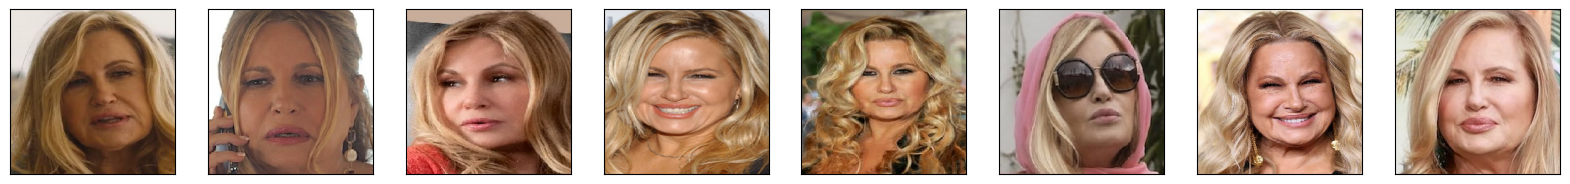

In [3]:
# Uploading and labelling images of Tanya
images, labels = load_images_from_path('/Users/shainalavergne/Desktop/White Lotus/Tanya', 0)
show_images(images)

x += images
y += labels

Loading: /Users/shainalavergne/Desktop/White Lotus/Armond/.DS_Store
Error: Cannot identify image file /Users/shainalavergne/Desktop/White Lotus/Armond/.DS_Store
Loading: /Users/shainalavergne/Desktop/White Lotus/Armond/image_10.png
Loading: /Users/shainalavergne/Desktop/White Lotus/Armond/image_8.png
Loading: /Users/shainalavergne/Desktop/White Lotus/Armond/image_9.jpg
Loading: /Users/shainalavergne/Desktop/White Lotus/Armond/Image_2.jpg
Loading: /Users/shainalavergne/Desktop/White Lotus/Armond/Image_3.jpg
Loading: /Users/shainalavergne/Desktop/White Lotus/Armond/Image_1.jpg
Loading: /Users/shainalavergne/Desktop/White Lotus/Armond/Image_4.jpg
Loading: /Users/shainalavergne/Desktop/White Lotus/Armond/Image_5.jpg
Loading: /Users/shainalavergne/Desktop/White Lotus/Armond/Image_7.png
Loading: /Users/shainalavergne/Desktop/White Lotus/Armond/Image_6.png


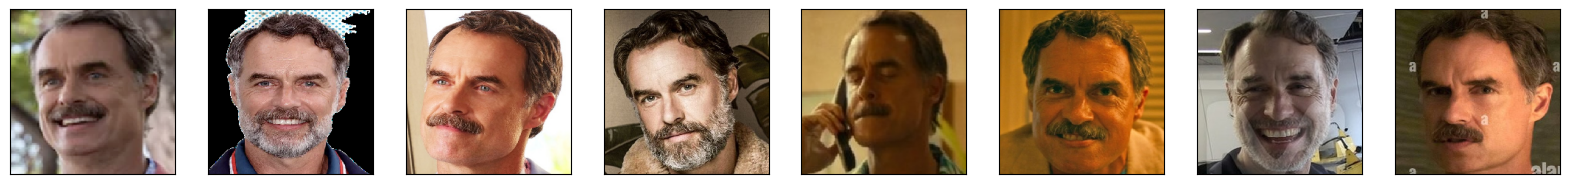

In [4]:
# Uploading and labelling images of Armond
images, labels = load_images_from_path('/Users/shainalavergne/Desktop/White Lotus/Armond', 1)
show_images(images)

x += images
y += labels

Loading: /Users/shainalavergne/Desktop/White Lotus/Harper/.DS_Store
Error: Cannot identify image file /Users/shainalavergne/Desktop/White Lotus/Harper/.DS_Store
Loading: /Users/shainalavergne/Desktop/White Lotus/Harper/Image_10.png
Loading: /Users/shainalavergne/Desktop/White Lotus/Harper/Image_8.jpg
Loading: /Users/shainalavergne/Desktop/White Lotus/Harper/Image_9.jpg
Loading: /Users/shainalavergne/Desktop/White Lotus/Harper/Image_3.jpg
Loading: /Users/shainalavergne/Desktop/White Lotus/Harper/Image_2.jpeg
Loading: /Users/shainalavergne/Desktop/White Lotus/Harper/Image_1.jpg
Loading: /Users/shainalavergne/Desktop/White Lotus/Harper/Image_4.jpg
Loading: /Users/shainalavergne/Desktop/White Lotus/Harper/Image_5.jpg
Loading: /Users/shainalavergne/Desktop/White Lotus/Harper/Image_7.jpg
Loading: /Users/shainalavergne/Desktop/White Lotus/Harper/Image_6.jpg


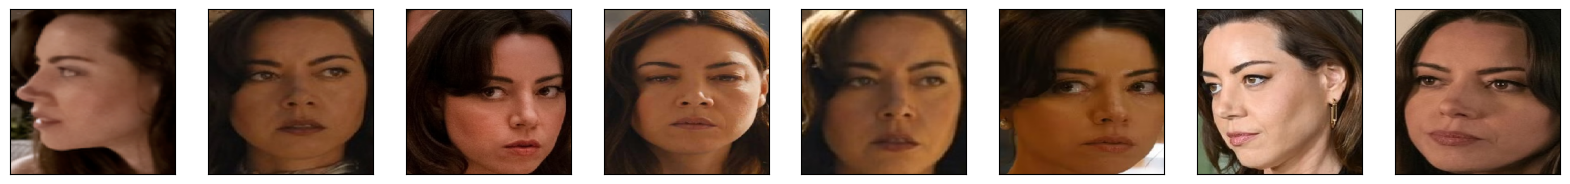

In [5]:
# Uploading and labelling images of Harper
images, labels = load_images_from_path('/Users/shainalavergne/Desktop/White Lotus/Harper', 2)
show_images(images)

x += images
y += labels

Loading: /Users/shainalavergne/Desktop/White Lotus/Daphne/.DS_Store
Error: Cannot identify image file /Users/shainalavergne/Desktop/White Lotus/Daphne/.DS_Store
Loading: /Users/shainalavergne/Desktop/White Lotus/Daphne/Image_10.jpg
Loading: /Users/shainalavergne/Desktop/White Lotus/Daphne/Image_8.jpg
Loading: /Users/shainalavergne/Desktop/White Lotus/Daphne/image_9.jpg
Loading: /Users/shainalavergne/Desktop/White Lotus/Daphne/Image_2.jpg
Loading: /Users/shainalavergne/Desktop/White Lotus/Daphne/Image_3.jpg
Loading: /Users/shainalavergne/Desktop/White Lotus/Daphne/Image_1.jpg
Loading: /Users/shainalavergne/Desktop/White Lotus/Daphne/Image_4.jpg
Loading: /Users/shainalavergne/Desktop/White Lotus/Daphne/Image_5.jpg
Loading: /Users/shainalavergne/Desktop/White Lotus/Daphne/Image_7.jpg
Loading: /Users/shainalavergne/Desktop/White Lotus/Daphne/Image_6.jpg
Loading: /Users/shainalavergne/Desktop/White Lotus/Daphne/Image_4.jpeg


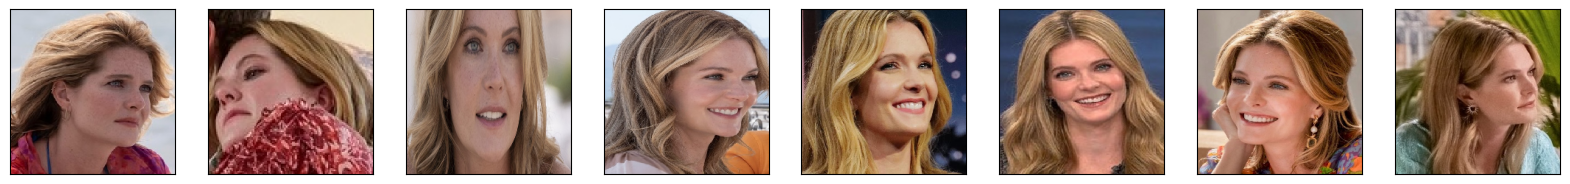

In [6]:
# Uploading and labelling images of Daphne
images, labels = load_images_from_path('/Users/shainalavergne/Desktop/White Lotus/Daphne', 3)
show_images(images)

x += images
y += labels

Loading: /Users/shainalavergne/Desktop/White Lotus/Timothy/.DS_Store
Error: Cannot identify image file /Users/shainalavergne/Desktop/White Lotus/Timothy/.DS_Store
Loading: /Users/shainalavergne/Desktop/White Lotus/Timothy/Image_10.jpg
Loading: /Users/shainalavergne/Desktop/White Lotus/Timothy/Image_8.jpg
Loading: /Users/shainalavergne/Desktop/White Lotus/Timothy/Image_9.jpg
Loading: /Users/shainalavergne/Desktop/White Lotus/Timothy/Image_2.jpg
Loading: /Users/shainalavergne/Desktop/White Lotus/Timothy/Image_3.jpg
Loading: /Users/shainalavergne/Desktop/White Lotus/Timothy/Image_1.JPG
Loading: /Users/shainalavergne/Desktop/White Lotus/Timothy/Image_4.jpg
Loading: /Users/shainalavergne/Desktop/White Lotus/Timothy/Image_5.jpg
Loading: /Users/shainalavergne/Desktop/White Lotus/Timothy/Image_7.jpg
Loading: /Users/shainalavergne/Desktop/White Lotus/Timothy/Image_6.jpg


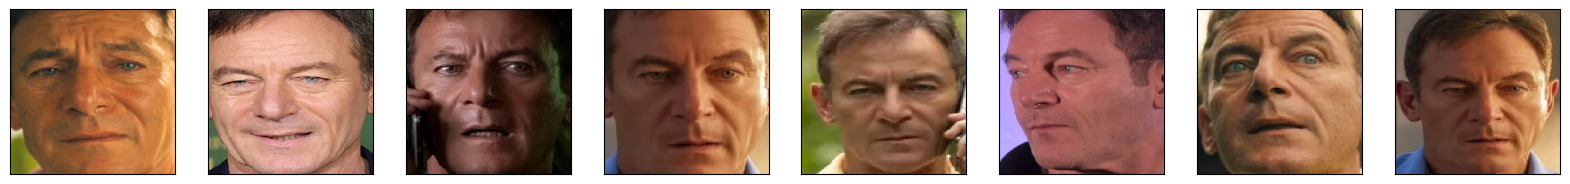

In [7]:
# Uploading and labelling images of Timothy
images, labels = load_images_from_path('/Users/shainalavergne/Desktop/White Lotus/Timothy', 4)
show_images(images)

x += images
y += labels

Loading: /Users/shainalavergne/Desktop/White Lotus/Jaclyn/.DS_Store
Error: Cannot identify image file /Users/shainalavergne/Desktop/White Lotus/Jaclyn/.DS_Store
Loading: /Users/shainalavergne/Desktop/White Lotus/Jaclyn/Image_10.jpg
Loading: /Users/shainalavergne/Desktop/White Lotus/Jaclyn/Image_8.jpg
Loading: /Users/shainalavergne/Desktop/White Lotus/Jaclyn/Image_9.jpg
Loading: /Users/shainalavergne/Desktop/White Lotus/Jaclyn/Image_2.jpg
Loading: /Users/shainalavergne/Desktop/White Lotus/Jaclyn/Image_3.jpg
Loading: /Users/shainalavergne/Desktop/White Lotus/Jaclyn/Image_1.jpg
Loading: /Users/shainalavergne/Desktop/White Lotus/Jaclyn/Image_4.jpg
Loading: /Users/shainalavergne/Desktop/White Lotus/Jaclyn/Image_5.jpg
Loading: /Users/shainalavergne/Desktop/White Lotus/Jaclyn/Image_7.jpg
Loading: /Users/shainalavergne/Desktop/White Lotus/Jaclyn/Image_6.jpg


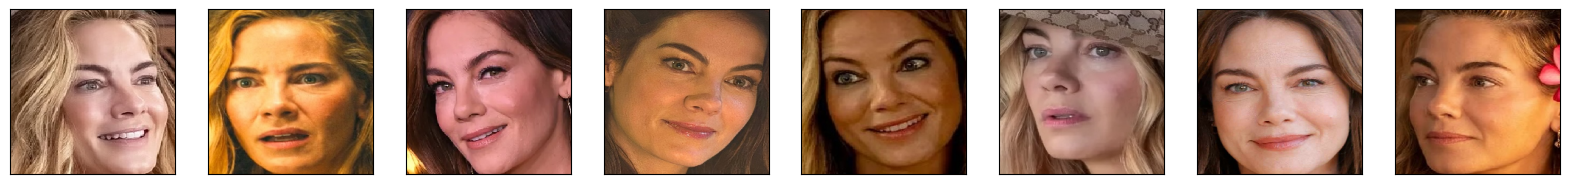

In [8]:
# Uploading and labelling images of Jaclyn
images, labels = load_images_from_path('/Users/shainalavergne/Desktop/White Lotus/Jaclyn', 5)
show_images(images)

x += images
y += labels

## Step 2: Prepare and Train the Model
- Use train test split from sklearn
- Use vggface.h5 as base_model
- Compile the model

In [9]:
import numpy as np
import sklearn
from sklearn.model_selection import train_test_split
from tensorflow.keras.applications.resnet50 import preprocess_input

faces = preprocess_input(np.array(x))
labels = np.array(y)
# splitting images into training and testing groups
x_train, x_test, y_train, y_test = train_test_split(faces, labels, train_size=0.2, stratify=labels, random_state=0)

In [10]:
from tensorflow.keras.models import load_model

base_model = load_model('/Users/shainalavergne/Desktop/White Lotus/vggface.h5')
base_model.trainable = False

Metal device set to: Apple M1


2025-04-30 11:17:55.707732: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:306] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-04-30 11:17:55.707827: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:272] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


In [11]:
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Flatten, Dense, Resizing

# compiling the model 
model = Sequential()
model.add(Resizing(224,224))
model.add(base_model)
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dense(len(labels), activation='softmax')) 
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [12]:
# Train the model 
hist = model.fit(x_train, y_train, validation_data=(x_test, y_test), batch_size=2, epochs=10)

Epoch 1/10


2025-04-30 11:17:56.736648: W tensorflow/core/platform/profile_utils/cpu_utils.cc:128] Failed to get CPU frequency: 0 Hz
2025-04-30 11:17:57.451574: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


5/6 [========================>.....] - ETA: 0s - loss: 8.4827 - accuracy: 0.0000e+00

2025-04-30 11:17:58.364459: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


6/6 [==============================] - 3s 324ms/step - loss: 7.1439 - accuracy: 0.0833 - val_loss: 1.1239 - val_accuracy: 0.7347
Epoch 2/10
6/6 [==============================] - 1s 190ms/step - loss: 0.0638 - accuracy: 1.0000 - val_loss: 0.7692 - val_accuracy: 0.8367
Epoch 3/10
6/6 [==============================] - 1s 141ms/step - loss: 0.0367 - accuracy: 1.0000 - val_loss: 1.4876 - val_accuracy: 0.7551
Epoch 4/10
6/6 [==============================] - 1s 140ms/step - loss: 0.0102 - accuracy: 1.0000 - val_loss: 1.4507 - val_accuracy: 0.7551
Epoch 5/10
6/6 [==============================] - 1s 140ms/step - loss: 9.5537e-04 - accuracy: 1.0000 - val_loss: 1.2963 - val_accuracy: 0.7347
Epoch 6/10
6/6 [==============================] - 1s 149ms/step - loss: 3.6024e-04 - accuracy: 1.0000 - val_loss: 1.2012 - val_accuracy: 0.7143
Epoch 7/10
6/6 [==============================] - 1s 151ms/step - loss: 2.6448e-04 - accuracy: 1.0000 - val_loss: 1.1283 - val_accuracy: 0.7143
Epoch 8/10
6/6 [===

## Step 3: Test the Model on Sample Images

In [13]:
from mtcnn.mtcnn import MTCNN
from PIL import Image, ImageOps
from tensorflow.keras.preprocessing import image
from matplotlib.patches import Rectangle

def get_face(image, face):
    x1, y1, w, h = face['box']
    
    if w > h:
        x1 = x1 + ((w - h) // 2)
        w = h
    elif h > w:
        y1 = y1 + ((h - w) // 2)
        h = w
        
    x2 = x1 + h
    y2 = y1 + w
    
    return image[y1:y2, x1:x2]

def label_faces(path, model, names, face_threshold=0.9, prediction_threshold=0.9, show_outline=True, size=(12, 8)):
    # Load the image and orient it correctly
    pil_image = Image.open(path)
    exif = pil_image.getexif()
    
    for k in exif.keys():
        if k != 0x0112:
            exif[k] = None
            del exif[k]
            
    pil_image.info["exif"] = exif.tobytes()
    pil_image = ImageOps.exif_transpose(pil_image)
    np_image = np.array(pil_image)

    fig, ax = plt.subplots(figsize=size, subplot_kw={'xticks': [], 'yticks': []})
    ax.imshow(np_image)

    detector = MTCNN()
    faces = detector.detect_faces(np_image)
    faces = [face for face in faces if face['confidence'] > face_threshold]

    for face in faces:
        x, y, w, h = face['box']

        # Use the model to identify the face
        face_image = get_face(np_image, face)
        face_image = image.array_to_img(face_image)
        face_image = preprocess_input(np.array(face_image))
        predictions = model.predict(np.expand_dims(face_image, axis=0))
        confidence = np.max(predictions)

        if (confidence > prediction_threshold):
        # Optionally draw a box around the face
            if show_outline:
                rect = Rectangle((x, y), w, h, color='red', fill=False, lw=2)
                ax.add_patch(rect)

            # Label the face
            index = int(np.argmax(predictions))
            text = f'{names[index]} ({confidence:.1%})'
            ax.text(x + (w / 2), y, text, color='white', backgroundcolor='red', ha='center', va='bottom', fontweight='bold', bbox=dict(color='red'))

1/1 [==============================] - 0s 122ms/step


2025-04-30 11:18:07.090399: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-04-30 11:18:07.223592: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


 1/19 [>.............................] - ETA: 2s

2025-04-30 11:18:08.121622: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


1/1 [==============================] - 0s 159ms/step


2025-04-30 11:18:08.408560: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-04-30 11:18:08.864693: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


1/1 [==============================] - 1s 713ms/step


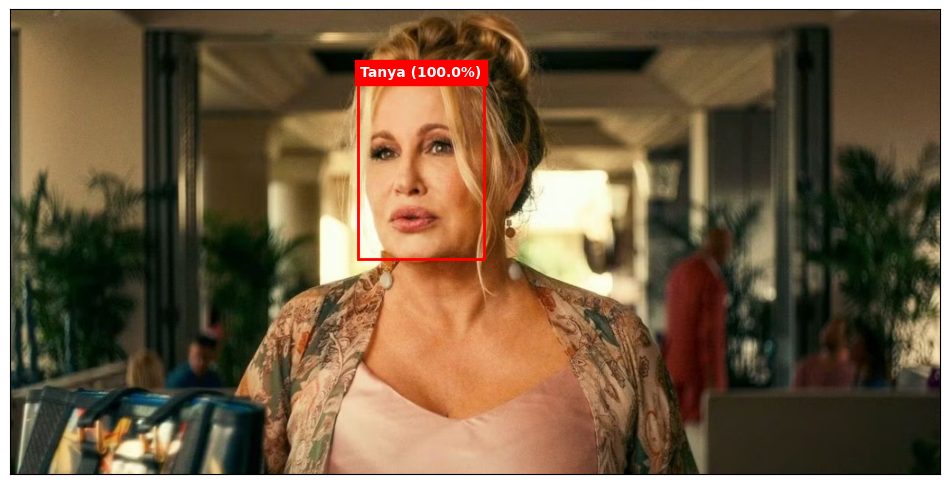

In [14]:
# Labelling faces in order of set indices (0-5)
labels = ['Tanya', 'Armond', 'Harper','Daphne','Timothy','Jaclyn']

# MTCNN is only used during prediction to locate faces in sample images.
# The training images were manually cropped and not generated via MTCNN.

# Testing sample image 1
label_faces('/Users/shainalavergne/Desktop/White Lotus/sample_data/sample_1.jpeg', model, labels)

1/1 [==============================] - 0s 97ms/step


2025-04-30 11:18:09.567635: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-04-30 11:18:09.684363: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


11/11 [==============================] - 0s 8ms/step


2025-04-30 11:18:10.473182: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


1/1 [==============================] - 0s 154ms/step


2025-04-30 11:18:10.709050: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-04-30 11:18:10.989600: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


1/1 [==============================] - 1s 546ms/step


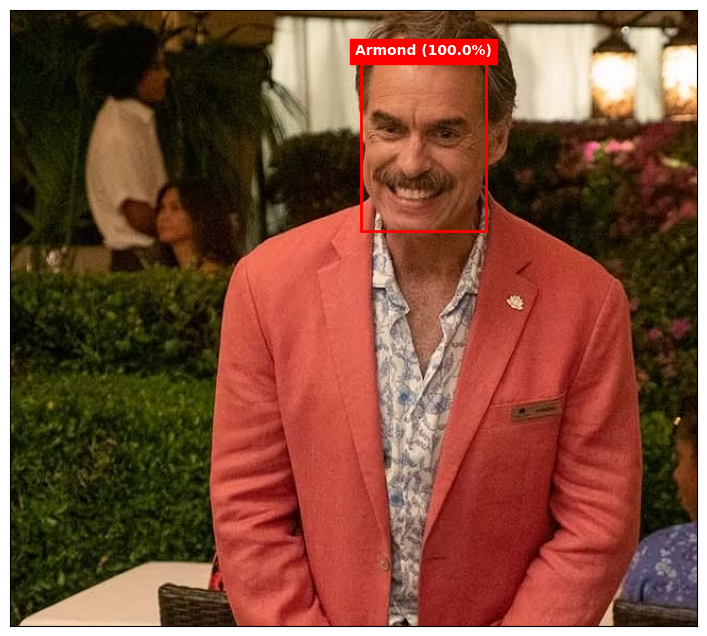

In [15]:
# Testing sample image # 2
label_faces('/Users/shainalavergne/Desktop/White Lotus/sample_data/sample_2.jpg', model, labels)

1/1 [==============================] - 0s 181ms/step


2025-04-30 11:18:11.674822: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


1/1 [==============================] - 0s 129ms/step


2025-04-30 11:18:11.897067: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


1/5 [=====>........................] - ETA: 0s

2025-04-30 11:18:12.964538: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


1/1 [==============================] - 0s 21ms/step


2025-04-30 11:18:13.235383: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


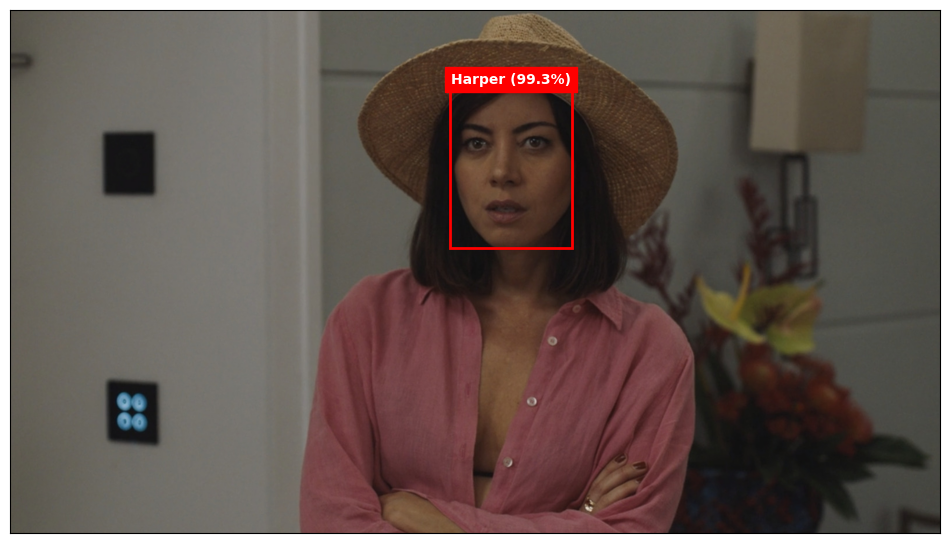

In [16]:
# Testing sample image # 3
label_faces('/Users/shainalavergne/Desktop/White Lotus/sample_data/sample_3.jpg', model, labels)

1/1 [==============================] - 0s 136ms/step


2025-04-30 11:20:12.276523: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-04-30 11:20:12.434641: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


 1/10 [==>...........................] - ETA: 1s

2025-04-30 11:20:13.475309: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


1/1 [==============================] - 0s 23ms/step


2025-04-30 11:20:13.790995: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


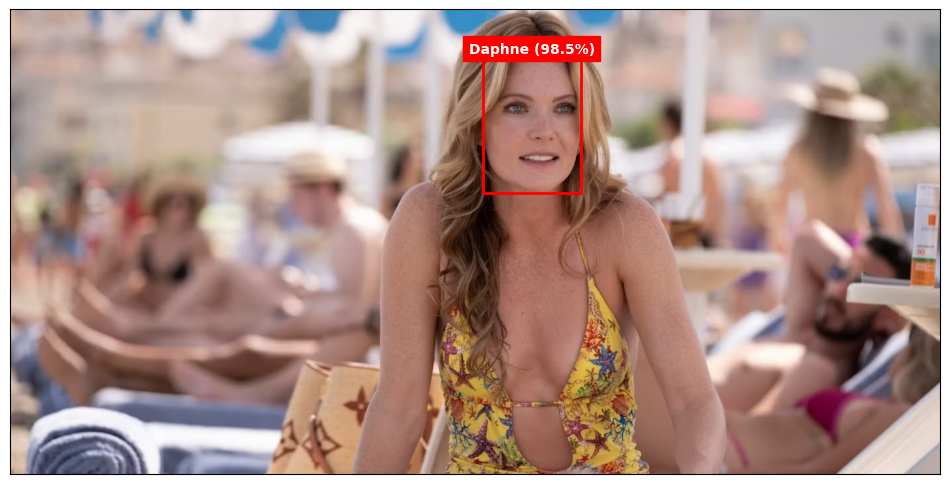

In [21]:
# Testing sample image # 4
label_faces('/Users/shainalavergne/Desktop/White Lotus/sample_data/sample_4.jpeg', model, labels)

1/1 [==============================] - 0s 147ms/step


2025-04-30 11:21:59.245155: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-04-30 11:21:59.423931: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


1/6 [====>.........................] - ETA: 0s

2025-04-30 11:22:00.533187: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


1/1 [==============================] - 0s 26ms/step


2025-04-30 11:22:00.795642: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


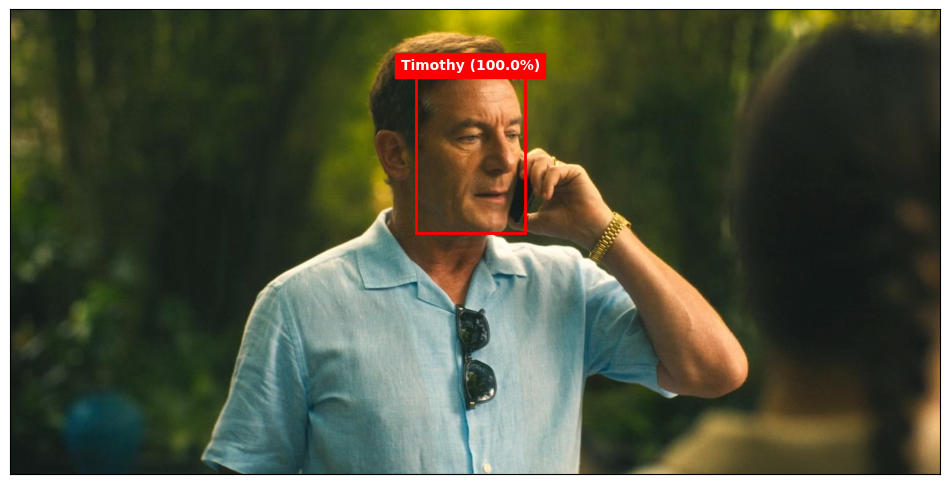

In [24]:
# Testing sample image # 5
label_faces('/Users/shainalavergne/Desktop/White Lotus/sample_data/sample_5.jpeg', model, labels)

1/1 [==============================] - 0s 143ms/step


2025-04-30 11:22:01.443169: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-04-30 11:22:01.610375: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


 1/20 [>.............................] - ETA: 3s

2025-04-30 11:22:02.705439: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


1/1 [==============================] - 0s 222ms/step


2025-04-30 11:22:03.017348: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


1/1 [==============================] - 0s 29ms/step


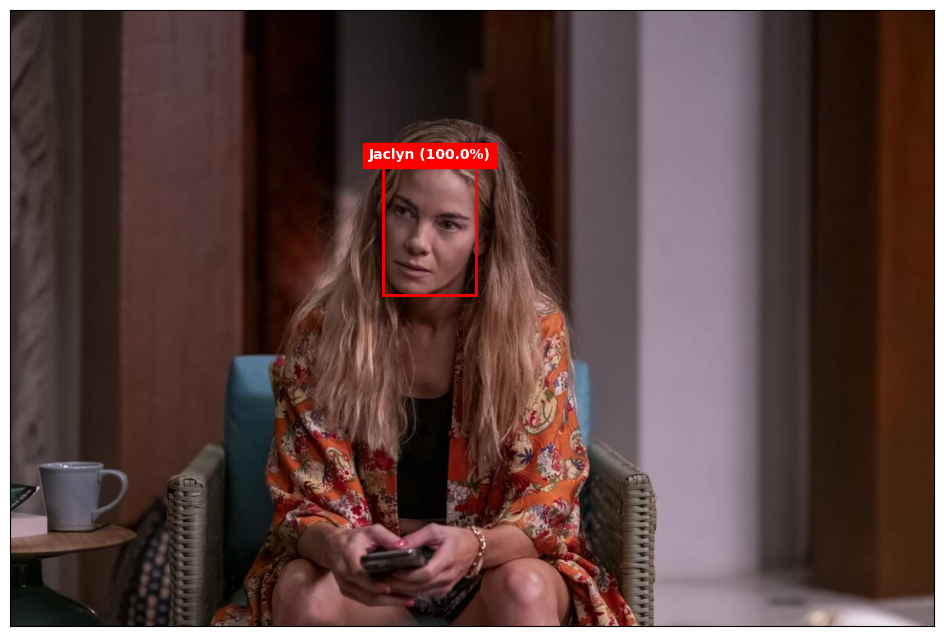

In [25]:
# Testing sample image # 6
label_faces('/Users/shainalavergne/Desktop/White Lotus/sample_data/sample_6.jpg', model, labels)